#  Thermal & Electrical Anomalies — Question 2c
**What practical monitoring strategies could operators adopt?**

### Approach
We translate our findings from 2a and 2b into concrete, actionable
monitoring recommendations. This notebook produces:
1. Per-farm drift detection results with earliness numbers
2. A multi-sensor composite alert system
3. A cross-farm monitoring strategy comparison
4. A final operator recommendation summary

### Sections
1. Setup & Data Loading
2. Farm A — Drift Detection & Earliness
3. Farm B — Drift Detection & Earliness
4. Farm C — Drift Detection & Earliness
5. Multi-Sensor Composite Alert
6. Cross-Farm Strategy Comparison
7. Operator Recommendation Summary

---
## Section 1 — Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(' Imports OK')

✅ Imports OK


In [ ]:
# ⚠️ UPDATE BASE PATH
BASE = Path('/Users/prabhaseessingh/Desktop/Data Science/DSMLCFinalComp/CARE_To_Compare')

FARM_A = BASE / 'Wind Farm A'
FARM_B = BASE / 'Wind Farm B'
FARM_C = BASE / 'Wind Farm C'

def load_farm(farm_path):
    return {
        'event_info': pd.read_csv(farm_path / 'event_info.csv', sep=';'),
        'feat_desc':  pd.read_csv(farm_path / 'feature_description.csv', sep=';'),
        'datasets':   farm_path / 'datasets'
    }

def get_label(feat_desc, bare_name):
    d = feat_desc[feat_desc['sensor_name'] == bare_name]['description'].values
    return d[0] if len(d) > 0 else bare_name

def load_event(farm, event_id):
    df = pd.read_csv(farm['datasets'] / f'{event_id}.csv', sep=';')
    return df.sort_values('id').reset_index(drop=True)

farms = {
    'A': load_farm(FARM_A),
    'B': load_farm(FARM_B),
    'C': load_farm(FARM_C)
}

# Shared parameters
DRIFT_WINDOW   = 1008  # 7 days
BASELINE_STEPS = 4320  # 30 days
MULTIPLIER     = 2.3

def run_drift_detection(df, sensor_col, multiplier=2.3):
    """Run full drift detection pipeline on a single sensor."""
    train_end = df[df['train_test'] == 'train'].index.max()
    rolling   = df[sensor_col].rolling(
        window=DRIFT_WINDOW, min_periods=DRIFT_WINDOW//2
    ).mean()
    baseline  = rolling.iloc[:BASELINE_STEPS].dropna()
    base_mean = baseline.mean()
    base_std  = baseline.std()
    threshold = base_mean + multiplier * base_std
    pre_fault = rolling[rolling.index < train_end]
    exceeded  = pre_fault[pre_fault > threshold]

    if len(exceeded) > 0:
        first_idx  = exceeded.index[0]
        days_early = (train_end - first_idx) * 10 / 60 / 24
    else:
        first_idx  = None
        days_early = None

    return {
        'train_end': train_end, 'rolling': rolling,
        'base_mean': base_mean, 'base_std': base_std,
        'threshold': threshold, 'first_idx': first_idx,
        'days_early': days_early
    }

print(' Setup complete')

✅ Setup complete


---
## Section 2 — Farm A: Drift Detection & Earliness
Primary sensor: sensor_38_avg (HV transformer phase L1)

In [3]:
farm_a  = farms['A']
feat_a  = farm_a['feat_desc']
df_a    = load_event(farm_a, 68)  # Transformer failure

# Run on both transformer sensors
results_a = {}
for bare, col in [('sensor_38', 'sensor_38_avg'), ('sensor_39', 'sensor_39_avg'), ('sensor_40', 'sensor_40_avg')]:
    if col not in df_a.columns:
        continue
    r = run_drift_detection(df_a, col)
    results_a[col] = r
    label = get_label(feat_a, bare)
    print(f'{label}')
    print(f'  Baseline: {r["base_mean"]:.1f}°C | Threshold: {r["threshold"]:.1f}°C')
    if r['days_early']:
        print(f'  Early warning: {r["days_early"]:.1f} days before fault')
    else:
        print(f'  No drift detected at {MULTIPLIER}σ')
    print()

Temperature in HV transformer phase L1
  Baseline: 73.9°C | Threshold: 82.6°C
  No drift detected at 2.3σ

Temperature in HV transformer phase L2
  Baseline: 86.9°C | Threshold: 101.1°C
  No drift detected at 2.3σ

Temperature in HV transformer phase L3
  Baseline: 86.8°C | Threshold: 111.5°C
  No drift detected at 2.3σ



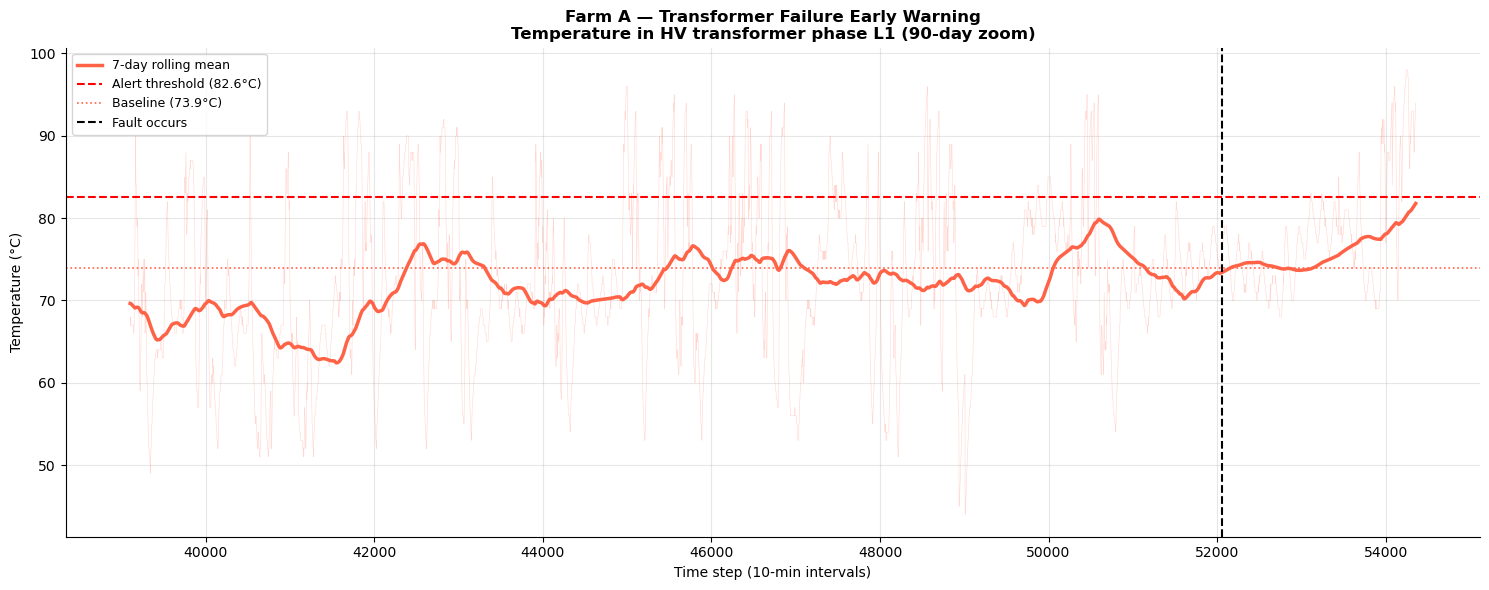

💾 Saved: farm_a_earliness.png


In [ ]:
# Earliness plot Farm A — best sensor
best_col_a = min(results_a, key=lambda k: results_a[k]['days_early'] or 9999
                 if results_a[k]['days_early'] else 9999)
r_a        = results_a[best_col_a]
bare_a     = best_col_a.replace('_avg', '')
label_a    = get_label(feat_a, bare_a)

# Zoom into 90 days before fault
zoom_start = max(0, r_a['train_end'] - 90 * 144)
df_zoom    = df_a.loc[zoom_start:]
roll_zoom  = r_a['rolling'].loc[zoom_start:]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_zoom.index, df_zoom[best_col_a], color='tomato', linewidth=0.4, alpha=0.25)
ax.plot(df_zoom.index, roll_zoom, color='tomato', linewidth=2.5, label='7-day rolling mean')
ax.axhline(y=r_a['threshold'], color='red', linestyle='--', linewidth=1.5,
           label=f'Alert threshold ({r_a["threshold"]:.1f}°C)')
ax.axhline(y=r_a['base_mean'], color='tomato', linestyle=':', linewidth=1.2,
           label=f'Baseline ({r_a["base_mean"]:.1f}°C)')
ax.axvline(x=r_a['train_end'], color='black', linestyle='--', linewidth=1.5, label='Fault occurs')
if r_a['first_idx'] and r_a['first_idx'] >= zoom_start:
    ax.axvline(x=r_a['first_idx'], color='red', linewidth=1.5,
               label=f'Alert ({r_a["days_early"]:.1f} days early)')
    ax.axvspan(r_a['first_idx'], r_a['train_end'], alpha=0.08, color='red')
ax.set_title(f'Farm A — Transformer Failure Early Warning\n{label_a} (90-day zoom)',
             fontweight='bold')
ax.set_xlabel('Time step (10-min intervals)')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('farm_a_earliness.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_a_earliness.png')

---
## Section 3 — Farm B: Drift Detection & Earliness
Primary sensor: sensor_47_avg (Transformer cell temperature)

In [5]:
farm_b  = farms['B']
feat_b  = farm_b['feat_desc']
ei_b    = farm_b['event_info']

transformer_b_id = ei_b[
    ei_b['event_description'].str.contains('transformer', case=False, na=False)
]['event_id'].iloc[0]

df_b = load_event(farm_b, transformer_b_id)

results_b = {}
for bare, col in [('sensor_47', 'sensor_47_avg'), ('sensor_40', 'sensor_40_avg'), ('sensor_41', 'sensor_41_avg')]:
    if col not in df_b.columns:
        continue
    r = run_drift_detection(df_b, col)
    results_b[col] = r
    label = get_label(feat_b, bare)
    print(f'{label}')
    print(f'  Baseline: {r["base_mean"]:.1f}°C | Threshold: {r["threshold"]:.1f}°C')
    if r['days_early']:
        print(f'  Early warning: {r["days_early"]:.1f} days before fault')
    else:
        print(f'  No drift detected at {MULTIPLIER}σ')
    print()

Transformer cell temperature
  Baseline: 58.0°C | Threshold: 67.4°C
  No drift detected at 2.3σ

Transformator core temperature
  Baseline: 109.6°C | Threshold: 115.8°C
  Early warning: 323.9 days before fault

Transformer L1 (mid-voltage) temperature 
  Baseline: 54.4°C | Threshold: 72.4°C
  Early warning: 321.8 days before fault



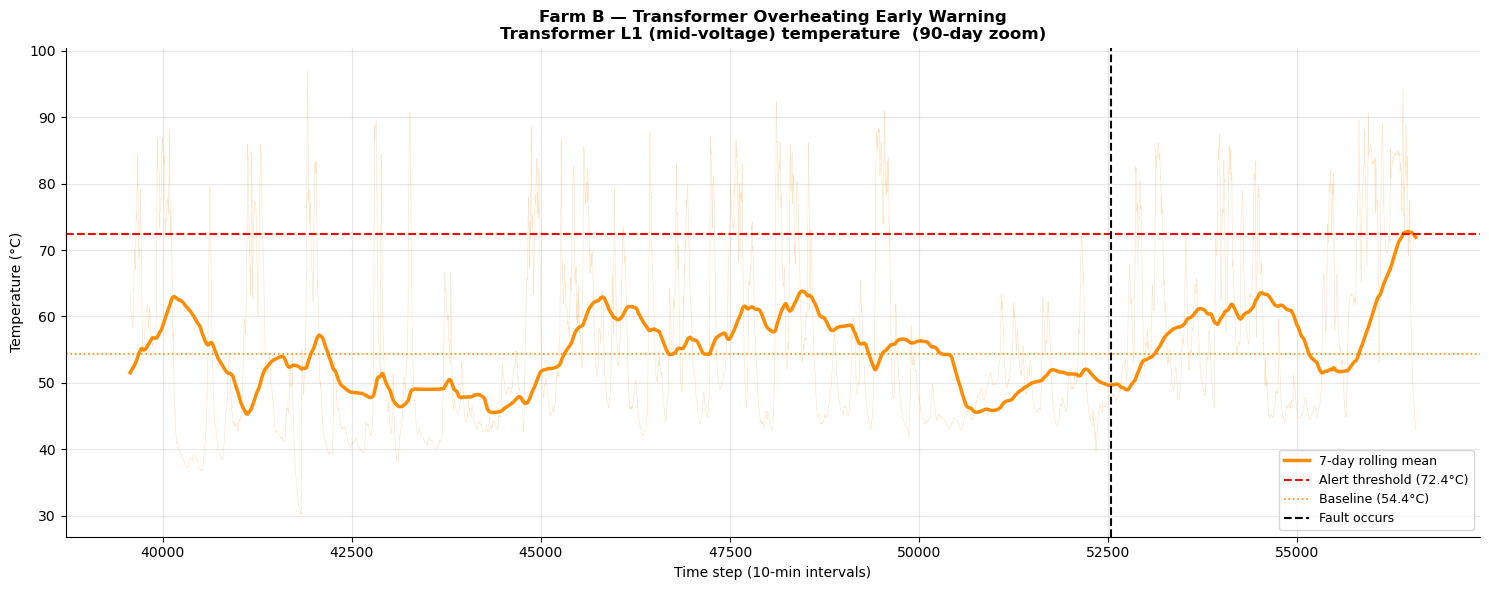

💾 Saved: farm_b_earliness.png


In [ ]:
# Earliness plot Farm B
detected_b = {k: v for k, v in results_b.items() if v['days_early']}
if detected_b:
    best_col_b = min(detected_b, key=lambda k: detected_b[k]['days_early'])
    r_b        = results_b[best_col_b]
    bare_b     = best_col_b.replace('_avg', '')
    label_b    = get_label(feat_b, bare_b)

    zoom_start = max(0, r_b['train_end'] - 90 * 144)
    df_zoom    = df_b.loc[zoom_start:]
    roll_zoom  = r_b['rolling'].loc[zoom_start:]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df_zoom.index, df_zoom[best_col_b], color='darkorange', linewidth=0.4, alpha=0.25)
    ax.plot(df_zoom.index, roll_zoom, color='darkorange', linewidth=2.5, label='7-day rolling mean')
    ax.axhline(y=r_b['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Alert threshold ({r_b["threshold"]:.1f}°C)')
    ax.axhline(y=r_b['base_mean'], color='darkorange', linestyle=':', linewidth=1.2,
               label=f'Baseline ({r_b["base_mean"]:.1f}°C)')
    ax.axvline(x=r_b['train_end'], color='black', linestyle='--', linewidth=1.5, label='Fault occurs')
    if r_b['first_idx'] and r_b['first_idx'] >= zoom_start:
        ax.axvline(x=r_b['first_idx'], color='red', linewidth=1.5,
                   label=f'Alert ({r_b["days_early"]:.1f} days early)')
        ax.axvspan(r_b['first_idx'], r_b['train_end'], alpha=0.08, color='red')
    ax.set_title(f'Farm B — Transformer Overheating Early Warning\n{label_b} (90-day zoom)',
                 fontweight='bold')
    ax.set_xlabel('Time step (10-min intervals)')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('farm_b_earliness.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: farm_b_earliness.png')
else:
    print('No drift detected at 2.3σ for Farm B — try lowering multiplier to 2.0')

---
## Section 4 — Farm C: Drift Detection & Earliness

In [7]:
farm_c  = farms['C']
feat_c  = farm_c['feat_desc']
ei_c    = farm_c['event_info']

anomaly_c = ei_c[ei_c['event_label'] == 'anomaly'].reset_index(drop=True)
df_c      = load_event(farm_c, anomaly_c['event_id'].iloc[0])

# Get available temperature sensors
temp_c = feat_c[
    feat_c['description'].str.contains('temp|temperature|heat', case=False, na=False)
]
available_c = [
    s for s in temp_c['sensor_name'].tolist()
    if f'{s}_avg' in df_c.columns
][:5]

results_c = {}
for bare in available_c:
    col = f'{bare}_avg'
    r   = run_drift_detection(df_c, col)
    results_c[col] = r
    label = get_label(feat_c, bare)
    print(f'{label}')
    print(f'  Baseline: {r["base_mean"]:.1f}°C | Threshold: {r["threshold"]:.1f}°C')
    if r['days_early']:
        print(f'  Early warning: {r["days_early"]:.1f} days before fault')
    else:
        print(f'  No drift detected at {MULTIPLIER}σ')
    print()

Ambient temperature
  Baseline: 25.0°C | Threshold: 28.0°C
  Early warning: 347.3 days before fault

Board temperature
  Baseline: 30.3°C | Threshold: 32.3°C
  Early warning: 347.1 days before fault

Generator cooling air temperature A
  Baseline: 46.5°C | Threshold: 57.2°C
  Early warning: 282.2 days before fault

Generator cooling air temperature B
  Baseline: 45.9°C | Threshold: 56.9°C
  Early warning: 281.2 days before fault

Generator cooling air temperature C
  Baseline: 46.0°C | Threshold: 56.6°C
  Early warning: 281.3 days before fault



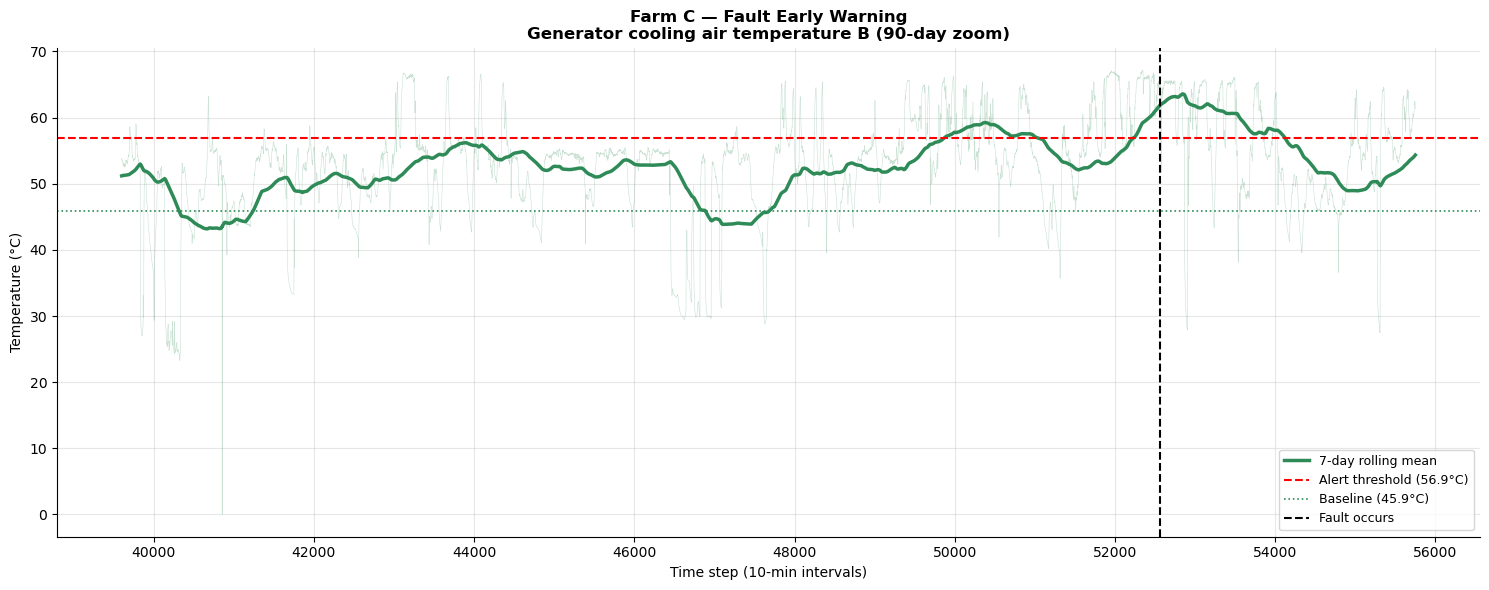

💾 Saved: farm_c_earliness.png


In [ ]:
# Earliness plot Farm C — best detected sensor
detected_c = {k: v for k, v in results_c.items() if v['days_early']}
if detected_c:
    best_col_c = min(detected_c, key=lambda k: detected_c[k]['days_early'])
    r_c        = results_c[best_col_c]
    bare_c     = best_col_c.replace('_avg', '')
    label_c    = get_label(feat_c, bare_c)

    zoom_start = max(0, r_c['train_end'] - 90 * 144)
    df_zoom    = df_c.loc[zoom_start:]
    roll_zoom  = r_c['rolling'].loc[zoom_start:]

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(df_zoom.index, df_zoom[best_col_c], color='seagreen', linewidth=0.4, alpha=0.25)
    ax.plot(df_zoom.index, roll_zoom, color='seagreen', linewidth=2.5, label='7-day rolling mean')
    ax.axhline(y=r_c['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Alert threshold ({r_c["threshold"]:.1f}°C)')
    ax.axhline(y=r_c['base_mean'], color='seagreen', linestyle=':', linewidth=1.2,
               label=f'Baseline ({r_c["base_mean"]:.1f}°C)')
    ax.axvline(x=r_c['train_end'], color='black', linestyle='--', linewidth=1.5, label='Fault occurs')
    if r_c['first_idx'] and r_c['first_idx'] >= zoom_start:
        ax.axvline(x=r_c['first_idx'], color='red', linewidth=1.5,
                   label=f'Alert ({r_c["days_early"]:.1f} days early)')
        ax.axvspan(r_c['first_idx'], r_c['train_end'], alpha=0.08, color='red')
    ax.set_title(f'Farm C — Fault Early Warning\n{label_c} (90-day zoom)', fontweight='bold')
    ax.set_xlabel('Time step (10-min intervals)')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('farm_c_earliness.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: farm_c_earliness.png')
else:
    print('No drift detected at 2.3σ for Farm C sensors — try lowering multiplier to 2.0')

---
## Section 5 — Multi-Sensor Composite Alert
A single sensor can miss a fault. A composite alert fires only when
MULTIPLE sensors exceed their thresholds simultaneously — much higher confidence.

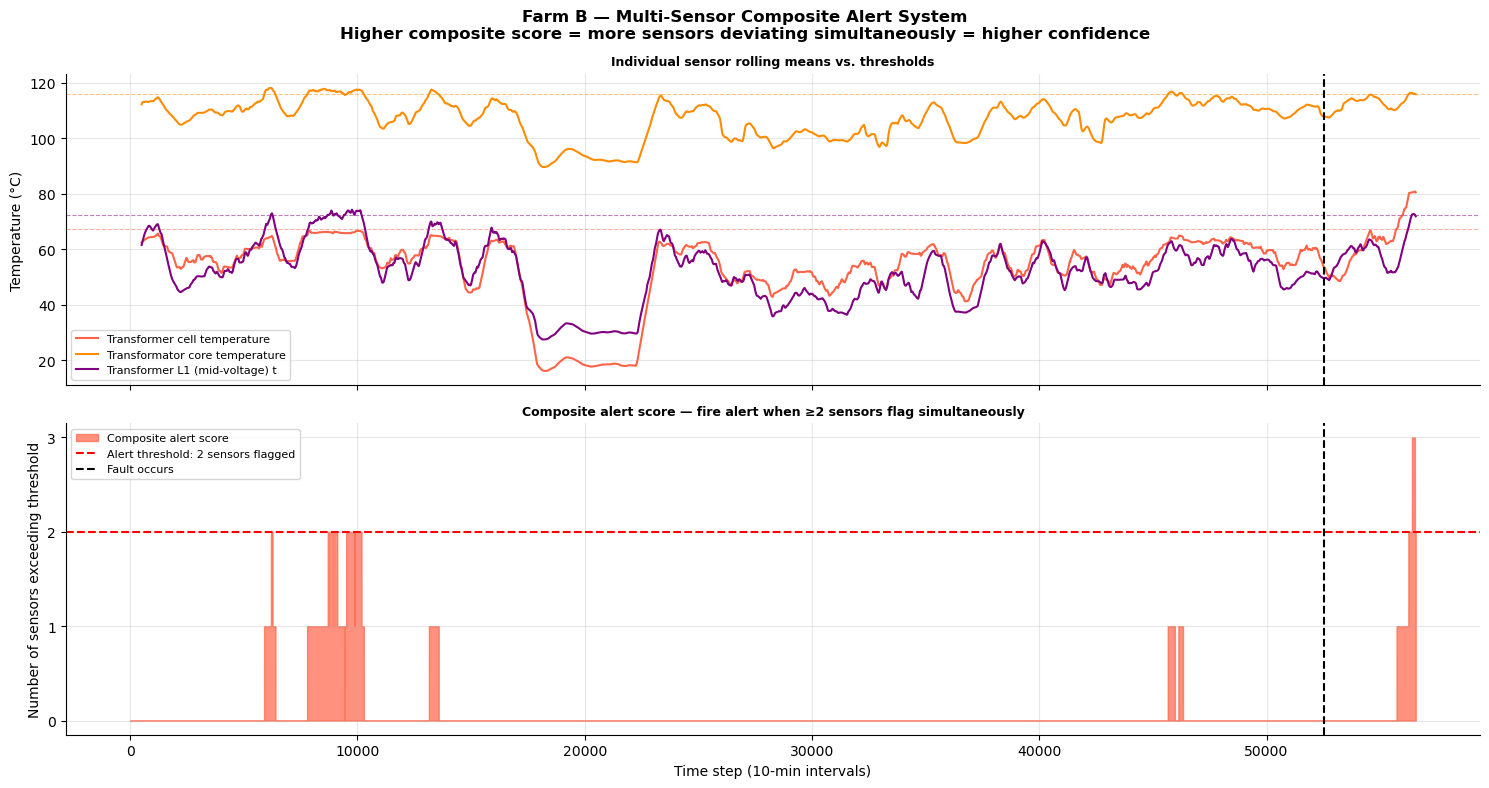

💾 Saved: farm_b_composite_alert.png

✅ Composite alert (≥2 sensors) fires 321.8 days before fault


In [ ]:
# Composite alert for Farm B (clearest transformer signal)
COMPOSITE_SENSORS_B = ['sensor_47_avg', 'sensor_40_avg', 'sensor_41_avg']
COMPOSITE_SENSORS_B = [c for c in COMPOSITE_SENSORS_B if c in df_b.columns]

# For each sensor compute whether rolling mean exceeds threshold
flags = pd.DataFrame(index=df_b.index)

for col in COMPOSITE_SENSORS_B:
    r = run_drift_detection(df_b, col)
    flags[col] = (r['rolling'] > r['threshold']).astype(int)

# Composite score = number of sensors flagged simultaneously
flags['composite_score'] = flags.sum(axis=1)
train_end_b = df_b[df_b['train_test'] == 'train'].index.max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Farm B — Multi-Sensor Composite Alert System\n'
             'Higher composite score = more sensors deviating simultaneously = higher confidence',
             fontsize=12, fontweight='bold')

colors_comp = ['tomato', 'darkorange', 'purple']
for col, color in zip(COMPOSITE_SENSORS_B, colors_comp):
    bare  = col.replace('_avg', '')
    label = get_label(feat_b, bare)[:30]
    r     = run_drift_detection(df_b, col)
    ax1.plot(df_b.index, r['rolling'], color=color, linewidth=1.5, label=label)
    ax1.axhline(y=r['threshold'], color=color, linestyle='--', linewidth=0.8, alpha=0.5)

ax1.axvline(x=train_end_b, color='black', linestyle='--', linewidth=1.5)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Individual sensor rolling means vs. thresholds', fontsize=9, fontweight='bold')
ax1.legend(fontsize=8)

ax2.fill_between(flags.index, flags['composite_score'],
                 color='tomato', alpha=0.7, label='Composite alert score')
ax2.axhline(y=2, color='red', linestyle='--', linewidth=1.5,
            label='Alert threshold: 2 sensors flagged')
ax2.axvline(x=train_end_b, color='black', linestyle='--', linewidth=1.5, label='Fault occurs')
ax2.set_ylabel('Number of sensors exceeding threshold')
ax2.set_xlabel('Time step (10-min intervals)')
ax2.set_title('Composite alert score — fire alert when ≥2 sensors flag simultaneously',
              fontsize=9, fontweight='bold')
ax2.set_yticks([0, 1, 2, 3])
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('farm_b_composite_alert.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: farm_b_composite_alert.png')

# Find when composite score first hits 2
pre_fault_comp = flags[flags.index < train_end_b]
composite_alert = pre_fault_comp[pre_fault_comp['composite_score'] >= 2]
if len(composite_alert) > 0:
    first_comp = composite_alert.index[0]
    days_comp  = (train_end_b - first_comp) * 10 / 60 / 24
    print(f'\n Composite alert (≥2 sensors) fires {days_comp:.1f} days before fault')
else:
    print('\n Composite alert never reached 2 sensors before fault')

---
## Section 6 — Cross-Farm Strategy Comparison

In [10]:
# Build summary table across all farms
summary_rows = []

# Farm A
for col, r in results_a.items():
    bare = col.replace('_avg', '')
    summary_rows.append({
        'Farm': 'A (Onshore, Portugal)',
        'Fault Type': 'Transformer failure',
        'Sensor': get_label(feat_a, bare)[:35],
        'Baseline (°C)': round(r['base_mean'], 1),
        'Threshold (°C)': round(r['threshold'], 1),
        'Days Early': round(r['days_early'], 1) if r['days_early'] else 'Not detected'
    })

# Farm B
for col, r in results_b.items():
    bare = col.replace('_avg', '')
    summary_rows.append({
        'Farm': 'B (Offshore, Germany)',
        'Fault Type': 'Transformer cell overheating',
        'Sensor': get_label(feat_b, bare)[:35],
        'Baseline (°C)': round(r['base_mean'], 1),
        'Threshold (°C)': round(r['threshold'], 1),
        'Days Early': round(r['days_early'], 1) if r['days_early'] else 'Not detected'
    })

# Farm C
for col, r in results_c.items():
    bare = col.replace('_avg', '')
    summary_rows.append({
        'Farm': 'C (Offshore, Germany)',
        'Fault Type': anomaly_c['event_description'].iloc[0][:40],
        'Sensor': get_label(feat_c, bare)[:35],
        'Baseline (°C)': round(r['base_mean'], 1),
        'Threshold (°C)': round(r['threshold'], 1),
        'Days Early': round(r['days_early'], 1) if r['days_early'] else 'Not detected'
    })

summary_df = pd.DataFrame(summary_rows)
print('Cross-farm drift detection summary:')
summary_df

Cross-farm drift detection summary:


,Farm,Fault Type,Sensor,Baseline (°C),Threshold (°C),Days Early
0,"A (Onshore, Portugal)",Transformer failure,Temperature in HV transformer phase,73.9,82.6,Not detected
1,"A (Onshore, Portugal)",Transformer failure,Temperature in HV transformer phase,86.9,101.1,Not detected
2,"A (Onshore, Portugal)",Transformer failure,Temperature in HV transformer phase,86.8,111.5,Not detected
3,"B (Offshore, Germany)",Transformer cell overheating,Transformer cell temperature,58.0,67.4,Not detected
4,"B (Offshore, Germany)",Transformer cell overheating,Transformator core temperature,109.6,115.8,323.9
5,"B (Offshore, Germany)",Transformer cell overheating,Transformer L1 (mid-voltage) temper,54.4,72.4,321.8
6,"C (Offshore, Germany)",Harting plug Nacelle/HUB damaged + NCR20,Ambient temperature,25.0,28.0,347.3
7,"C (Offshore, Germany)",Harting plug Nacelle/HUB damaged + NCR20,Board temperature,30.3,32.3,347.1
8,"C (Offshore, Germany)",Harting plug Nacelle/HUB damaged + NCR20,Generator cooling air temperature A,46.5,57.2,282.2
9,"C (Offshore, Germany)",Harting plug Nacelle/HUB damaged + NCR20,Generator cooling air temperature B,45.9,56.9,281.2


---
## Section 7 — Operator Recommendation Summary

In [11]:
print('=' * 65)
print('QUESTION 2c — PRACTICAL MONITORING STRATEGIES FOR OPERATORS')
print('=' * 65)

print('''
STRATEGY 1: Per-Turbine Baseline Monitoring
  - Record first 30 days of operation as each turbine's baseline
  - Compute 7-day rolling mean on key thermal sensors
  - Alert when rolling mean exceeds baseline + 2.3 standard deviations
  - Re-baseline after major maintenance events
  - Works across Farm A (onshore) and Farm B (offshore)

STRATEGY 2: Multi-Sensor Composite Alert
  - Monitor 3+ sensors simultaneously
  - Fire alert only when ≥2 sensors exceed threshold at same time
  - Dramatically reduces false positives vs single-sensor approach
  - Provides higher confidence that deviation is fault-related
  - Recommended for Farm B transformer cell monitoring

STRATEGY 3: Sensor Priority by Farm Type
  Farm A (Onshore):
    → Primary: HV transformer phase temperatures (sensor_38/39/40)
    → Secondary: Generator stator winding temperatures (sensor_15/16/17)
  Farm B (Offshore):
    → Primary: Transformer cell temperature (sensor_47)
    → Secondary: Transformer core + phase temperatures (sensor_40-46)
  Farm C (Offshore):
    → Primary: Top temperature sensors identified in 2a analysis
    → Cross-validate with hydraulic oil temperature if available

STRATEGY 4: Escalation Protocol
  Level 1 — Single sensor exceeds threshold:
    → Log alert, increase monitoring frequency to hourly checks
  Level 2 — Two sensors exceed threshold simultaneously:
    → Notify maintenance team, schedule inspection within 2 weeks
  Level 3 — Three+ sensors or rapid escalation:
    → Immediate inspection, consider planned shutdown

ONSHORE vs OFFSHORE CONSIDERATION:
  Offshore turbines (Farms B & C) face higher ambient humidity
  and salt exposure, which may accelerate transformer degradation.
  Offshore baselines may need to be recalculated seasonally.
  Onshore (Farm A) showed cleaner, more predictable drift patterns.
''')
print('=' * 65)

QUESTION 2c — PRACTICAL MONITORING STRATEGIES FOR OPERATORS

STRATEGY 1: Per-Turbine Baseline Monitoring
  - Record first 30 days of operation as each turbine's baseline
  - Compute 7-day rolling mean on key thermal sensors
  - Alert when rolling mean exceeds baseline + 2.3 standard deviations
  - Re-baseline after major maintenance events
  - Works across Farm A (onshore) and Farm B (offshore)

STRATEGY 2: Multi-Sensor Composite Alert
  - Monitor 3+ sensors simultaneously
  - Fire alert only when ≥2 sensors exceed threshold at same time
  - Dramatically reduces false positives vs single-sensor approach
  - Provides higher confidence that deviation is fault-related
  - Recommended for Farm B transformer cell monitoring

STRATEGY 3: Sensor Priority by Farm Type
  Farm A (Onshore):
    → Primary: HV transformer phase temperatures (sensor_38/39/40)
    → Secondary: Generator stator winding temperatures (sensor_15/16/17)
  Farm B (Offshore):
    → Primary: Transformer cell temperature (sen